A)

In [1]:
from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import _LinearRegression
import OLS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [2]:
def Runge_func(x):
    return 1.0/(1 + 25*x**2)

In [24]:
np.random.seed(2025)

degree = 1

xs = np.random.randn(1000)[:,np.newaxis]

X = PolynomialFeatures(degree, include_bias=False).fit_transform(xs)

ys = Runge_func(xs)

X_train, X_test, y_train, y_test = train_test_split(X, ys, train_size=0.8)

scalerx = StandardScaler()
scalerx.fit(X_train)
X_train = scalerx.transform(X_train)
X_test  = scalerx.transform(X_test)

scalery = StandardScaler()
scalery.fit(y_train)
y_train = scalery.transform(y_train)
y_test = scalery.transform(y_test)
y_mean = scalery.mean_
print(y_mean)

[0.22506289]


In [3]:
np.random.seed(2025)

n = 1000
x = np.linspace(-1, 1, n)

std = 0.1
y = Runge_func(x) + np.random.normal(0, std, size=n)

degree = 12

x = x.reshape(-1, 1)
y = y.reshape(-1,1)

X = PolynomialFeatures(degree, include_bias=False).fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Add bias manually, for OLS fit
X_train_s_bias = np.hstack([np.ones((X_train_s.shape[0], 1)), X_train_s])
X_test_s_bias = np.hstack([np.ones((X_test_s.shape[0], 1)), X_test_s])

scaler_y = StandardScaler()
scaler_y.fit(y_train)
y_train_s = scaler_y.transform(y_train)
y_test_s = scaler_y.transform(y_test)

In [89]:
# Fine best batch and epoch size

np.random.seed(2025)

num_input_feats = 1 # Number of input features
num_output_feats = 1 # Number og output features

batch_sizes = np.array([10, 50, 100])
epochs = np.array([10, 100, 200])

MSE_test_matrix = np.zeros([len(batch_sizes), len(epochs)])

scheduler = Adam(0.001)

for i in range(len(batch_sizes)):
    for j in range(len(epochs)):

        np.random.seed(2025)

        # Setting up FFNN, important do to this for each iterations so we can match with seed later
        ffnn = NeuralNetwork(num_input_feats, num_output_feats, [100,100], [sigmoid, sigmoid, id_func], 
                            [sigmoid_der, sigmoid_der, id_func_der], scheduler, mse, mse_der,
                            regularization = None, reg_param=0
                            )
        
        #Train
        ffnn.train(X_train_s[:, 0].reshape(-1,1), y_train_s, batch_sizes[i], epochs[j])
        
        test_pred = ffnn.predict(X_test_s[:, 0].reshape(-1,1))
        
        test_pred = scaler_y.inverse_transform(test_pred)

        MSE_test_matrix[i, j] = mean_squared_error(test_pred, y_test)

In [67]:
MSE_test_matrix

array([[0.02423061, 0.0098403 , 0.00978517],
       [0.33254891, 0.0188146 , 0.01372698],
       [0.6464245 , 0.07636044, 0.03656787]])

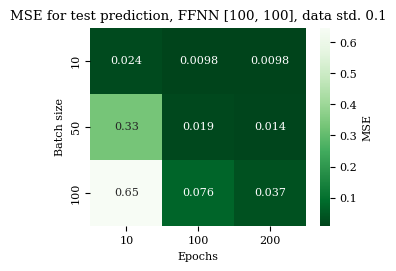

In [90]:
import seaborn as sns

import matplotlib
from matplotlib.ticker import MultipleLocator

MM_TO_INCH = 1/25.4

matplotlib.rc("text", usetex=False)
plt.rc('lines', linewidth=1.0)
plt.rc("figure", autolayout=True)
plt.rc("legend", fontsize=6)
plt.rc("font", family="serif", size=8)
plt.figure(figsize=(86.78*MM_TO_INCH, 70*MM_TO_INCH))
# # plt.ticklabel_format(axis = "y", style="sci")
# # plt.gca().xaxis.set_major_locator(MultipleLocator(base=1, offset=1))   # Configure the markers on the x axis
# # plt.grid(True, which="both", linestyle="--", linewidth=0.25)

sns.heatmap(MSE_test_matrix, annot=True, cmap="Greens_r", xticklabels=epochs, yticklabels=batch_sizes, cbar_kws={"label": "MSE"}, fmt=".2g")
plt.xlabel("Epochs")
plt.ylabel("Batch size")
plt.title(f"MSE for test prediction, FFNN [100, 100], data std. {std}")
plt.savefig("heatmap_MSE_FNN_100_100.pdf", bbox_inches="tight")
plt.show()
plt.close()

In [91]:
# Fine best batch and epoch size

np.random.seed(2025)

num_input_feats = 1 # Number of input features
num_output_feats = 1 # Number og output features

batch_sizes = np.arange(5,11,1)
epochs = np.array([100])

MSE_test_matrix = np.zeros([len(batch_sizes), len(epochs)])

scheduler = Adam(0.001)

for i in range(len(batch_sizes)):
    for j in range(len(epochs)):

        np.random.seed(2025)

        # Setting up FFNN, important do to this for each iterations so we can match with seed later
        ffnn = NeuralNetwork(num_input_feats, num_output_feats, [100,100], [sigmoid, sigmoid, id_func], 
                            [sigmoid_der, sigmoid_der, id_func_der], scheduler, mse, mse_der,
                            regularization = None, reg_param=0
                            )
        
        #Train
        ffnn.train(X_train_s[:, 0].reshape(-1,1), y_train_s, batch_sizes[i], epochs[j])
        
        test_pred = ffnn.predict(X_test_s[:, 0].reshape(-1,1))
        
        test_pred = scaler_y.inverse_transform(test_pred)

        MSE_test_matrix[i, j] = mean_squared_error(test_pred, y_test)

In [92]:
MSE_test_matrix

array([[0.00969683],
       [0.0102343 ],
       [0.00920027],
       [0.00937581],
       [0.00948701],
       [0.0098403 ]])

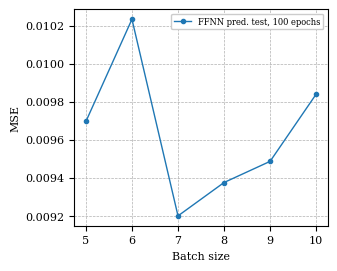

In [103]:
import seaborn as sns

import matplotlib
from matplotlib.ticker import MultipleLocator

MM_TO_INCH = 1/25.4

matplotlib.rc("text", usetex=False)
plt.rc('lines', linewidth=1.0)
plt.rc("figure", autolayout=True)
plt.rc("legend", fontsize=6)
plt.rc("font", family="serif", size=8)
plt.figure(figsize=(86.78*MM_TO_INCH, 70*MM_TO_INCH))
# # plt.ticklabel_format(axis = "y", style="sci")
# # plt.gca().xaxis.set_major_locator(MultipleLocator(base=1, offset=1))   # Configure the markers on the x axis
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.plot(batch_sizes, MSE_test_matrix, ".-", label="FFNN pred. test, 100 epochs")
plt.xlabel("Batch size")
plt.ylabel("MSE")
# plt.title(f"MSE for test prediction, FFNN [100, 100], data std. {std}")
plt.legend().get_frame().set_alpha(1.0) # Add solid background (non see thru) to legend box
plt.savefig("plot_MSE_batchsize_FFNN_100_100.pdf", bbox_inches="tight")
plt.show()
plt.close()

In [105]:
# Setup FFNN

np.random.seed(2025)

num_input_feats = 1 # Number of input features
num_output_feats = 1 # Number og output features

batch_size = 7
epochs = 100

scheduler = Adam(0.001)
ffnn = NeuralNetwork(num_input_feats, num_output_feats, [100,100], [sigmoid, sigmoid, id_func], 
                    [sigmoid_der, sigmoid_der, id_func_der], scheduler, mse, mse_der,
                     regularization = None, reg_param=0
                    )


ffnn.train(X_train_s[:, 0].reshape(-1,1), y_train_s, batch_size, epochs)

In [106]:
train_pred = ffnn.predict(X_train_s[:, 0].reshape(-1,1))
test_pred = ffnn.predict(X_test_s[:, 0].reshape(-1,1))

In [107]:
# OLS model
model_OLS = OLS.OLS(gd_method="analytic")
model_OLS.fit(X_train_s_bias, y_train)
test_pred_OLS = model_OLS.predict(X_test_s_bias)

Test MSE FFNN: 0.009200269914601265
Test MSE OLS: 0.009460239847396397


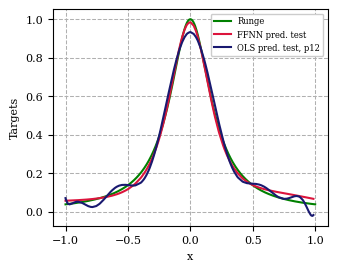

In [140]:
test_pred_plot = scaler_y.inverse_transform(test_pred)

XX_train = X_train[:, 0] # The x^1 values
XX_test = X_test[:, 0] # The x^1 values

sorted_indices_XX_train = np.argsort(XX_train)
sorted_indices_XX_test = np.argsort(XX_test)

XX_train_sorted = XX_train[sorted_indices_XX_train]
XX_test_sorted = XX_test[sorted_indices_XX_test]

y_train_sorted = y_train[sorted_indices_XX_train]
y_test_sorted = y_test[sorted_indices_XX_test]
test_pred_plot_sorted = test_pred_plot[sorted_indices_XX_test]
test_pred_OLS_sorted = test_pred_OLS[sorted_indices_XX_test]

# test_pred_plot_sorted = test_pred_plot[sorted_indices_XX_test]
# pred_test_OLS_sorted = pred_test_OLS[sorted_indices_XX_test]

print("Test MSE FFNN:", mean_squared_error(test_pred_plot, y_test))
print("Test MSE OLS:", mean_squared_error(test_pred_OLS, y_test))

matplotlib.rc("text", usetex=False)
plt.rc('lines', linewidth=1.0)
plt.rc("figure", autolayout=True)
plt.rc("legend", fontsize=6)
plt.rc("font", family="serif", size=8)
plt.figure(figsize=(86.78*MM_TO_INCH, 70*MM_TO_INCH))

plt.plot(x, Runge_func(x), "-", label="Runge", linewidth="1.5", color="green")
# plt.plot(XX_train_sorted, y_train_sorted, ".", markersize="1.0", label=f"Train data {std}")
# plt.plot(XX_test_sorted, y_test_sorted, ".", markersize="1.0", label=f"Test data {std}")
plt.plot(XX_test_sorted, test_pred_plot_sorted, "-", linewidth="1.5", label="FFNN pred. test", color="crimson")
plt.plot(XX_test_sorted, test_pred_OLS_sorted, "-", linewidth="1.5", label=f"OLS pred. test, p{degree}", color="midnightblue")
plt.xlabel("x")
plt.ylabel("Targets")
plt.legend().get_frame().set_alpha(1.0) # Add solid background (non see thru) to legend box
plt.grid(True, which="both", linestyle="--", linewidth=0.75)
plt.savefig("plot_MSE_test_FFNN_OLS.pdf", bbox_inches="tight")
plt.show()
plt.close()

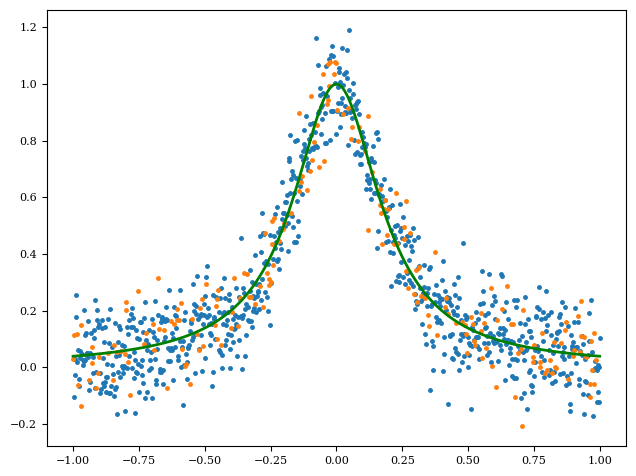

In [146]:
plt.plot(XX_train_sorted, y_train_sorted, ".", markersize="5.0", label=f"Train data {std}")
plt.plot(XX_test_sorted, y_test_sorted, ".", markersize="5.0", label=f"Test data {std}")
plt.plot(x, Runge_func(x), "-", label="Runge", linewidth="2.0", color="green")